In [1]:
import numpy as np
import numpy.random as nprand
import matplotlib.pyplot as plt
from scipy.stats import gamma
import matplotlib.colors as mcolors

In [ ]:
### CODE 1D

def f_quadratic_worst_case(t,mu,L):
    obj_return = np.empty(len(t))
    obj_return[np.where(t<0)] = 0.5*mu*t[np.where(t<0)[0]]**2
    obj_return[np.where(t>=0)] = 0.5*L*t[np.where(t>=0)[0]]**2
    return obj_return


def f_pl_worst_case(t,mu_0,mu,L):
    obj_return = np.empty(len(t))
    obj_return[np.where(t<0)] = 0.5*mu_0*t[np.where(t<0)[0]]**2
    obj_return[np.where(t>=0)] = 0.5*L*t[np.where(t>=0)[0]]**2 + 3*mu*np.sin(5*t[np.where(t>=0)[0]])*t[np.where(t>=0)[0]]**2
    return obj_return    

def f_1d(t,a,b):
    return 0.5*5*(t+a*np.sin(b*t))**2 
def f_1d_deriv(t,a,b):
    return 5*(t+a*np.sin(b*t))*(1+a*b*np.cos(b*t))
def f_1d_hess(t,a,b):
    return 5*(1+a*b*np.cos(b*t))*(1+a*b*np.cos(b*t)) - 5*(t+a*np.sin(b*t))*(a*b*b*np.sin(b*t))
### CODE 2D

def h(r):
    return 0.5*r**2  # décroissance radiale
def h_prime(r):  
    return r
def g(u, v,nb_f,a,b):
    # nb_f = 10
    # a,c = nprand.uniform(0,15,nb_f), nprand.uniform(0,15,nb_f)
    # b,d = nprand.uniform(-25,25,nb_f), nprand.uniform(-25,25,nb_f)
    return_var = 0
    for i in range(nb_f):
        return_var += a[i]*np.sin(b[i]*u)**2 + c[i]*np.cos(d[i]*v)**2
    return return_var/nb_f + 1 # dépend uniquement de la direction

def grad_g(u, v,nb_f,a,b):
    # nb_f = 10

    return_var = np.zeros(2)
    for i in range(nb_f):
        return_var[0] +=  2*b[i]*a[i]*np.sin(b[i]*u)*np.cos(b[i]*u) 
        return_var[1] += - 2*d[i]*c[i]*np.cos(d[i]*u)*np.sin(d[i]*u)
    return return_var/nb_f # dépend uniquement de la direction


def f(x, y,nb_f,a,b):
    r = np.sqrt(x**2 + y**2)
    # éviter la division par zéro
    u = np.where(r != 0, x/r, 0.0)
    v = np.where(r != 0, y/r, 0.0)
    return h(r) * g(u, v,nb_f,a,b)

def grad_f(x, y,nb_f,a,b):
    r = np.sqrt(x**2 + y**2)
    # éviter la division par zéro
    u = np.where(r != 0, x/r, 0.0)
    v = np.where(r != 0, y/r, 0.0)
    return np.array([u,v])/r * g(u, v,nb_f,a,b) + h(r)* grad_g(u,v,nb_f,a,b)

In [3]:
x_min = -2
x_max = 2
nb_step = 1000000
tt = np.linspace(x_min, x_max, nb_step)
a_1d = 0.2
b_1d = 5
# --- # Test of GEOMETRICAL CONDITIONS on 1d function # --- #
pl = 0.5*f_1d_deriv(tt,a_1d,b_1d)**2/f_1d(tt,a_1d,b_1d)
rsi = np.abs(f_1d_deriv(tt,a_1d,b_1d)/(tt))
qg =  2*f_1d(tt,a_1d,b_1d)/tt**2
pl_const = np.min(pl)
rsi_const  = np.min(rsi)
qg_upp = np.max(qg)
qg_inf = np.min(qg)
arg_inf = np.argmin(rsi_const)
L_const = np.max(np.abs(f_1d_hess(tt, a_1d, b_1d)))

print("start strongly quasar convex")
#---# Special case: test of quasar convex #---#
gamma = np.linspace(1*10**(-15),2.4*10**(-13),100)
max_val_acc = 0
max_val_gd = 0
L = np.abs(f_1d_hess(tt,a_1d,b_1d)).max()
vec_mu=np.empty(100)
k = 0
for i in gamma:
    sqc_mu_cst = -2*(f_1d(tt,a_1d,b_1d) - i**(-1)*f_1d_deriv(tt,a_1d,b_1d)*tt)/(tt**2)
    
    print("gamma = ", i, ", mu = ", sqc_mu_cst.min(), ", gamma sqrt mu/L = ",np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L), ", gamma mu/L = ", (sqc_mu_cst).min()*i/L)
    max_val_acc = np.nanmax([np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L),max_val_acc])
    max_val_gd = np.nanmax([(sqc_mu_cst).min()*i/L,max_val_gd])
    vec_mu[k] = sqc_mu_cst.min()
    k+=1

functions_values =f_1d(tt, a_1d, b_1d)

start strongly quasar convex
gamma =  1e-15 , mu =  1186.2691219288292 , gamma sqrt mu/L =  5.3709361518301285e-15 , gamma mu/L =  2.8846955147035826e-14
gamma =  3.414141414141414e-15 , mu =  343.9220220183662 , gamma sqrt mu/L =  9.873471457131397e-15 , gamma mu/L =  2.8553427286580025e-14
gamma =  5.8282828282828285e-15 , mu =  199.39453000599894 , gamma sqrt mu/L =  1.2833810289788436e-14 , gamma mu/L =  2.8259899426124224e-14
gamma =  8.242424242424242e-15 , mu =  139.52897571656257 , gamma sqrt mu/L =  1.5182578798264456e-14 , gamma mu/L =  2.796637156566843e-14
gamma =  1.0656565656565656e-14 , mu =  106.78734081134473 , gamma sqrt mu/L =  1.7172579184516166e-14 , gamma mu/L =  2.7672843705212622e-14
gamma =  1.307070707070707e-14 , mu =  86.14037475055822 , gamma sqrt mu/L =  1.8917373422417423e-14 , gamma mu/L =  2.7379315844756824e-14
gamma =  1.5484848484848483e-14 , mu =  71.93127547193478 , gamma sqrt mu/L =  2.0479729564367566e-14 , gamma mu/L =  2.7085787984301026e-14
ga

/tmp/ipykernel_8646/853816029.py:29: RuntimeWarning: invalid value encountered in sqrt
  print("gamma = ", i, ", mu = ", sqc_mu_cst.min(), ", gamma sqrt mu/L = ",np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L), ", gamma mu/L = ", (sqc_mu_cst).min()*i/L)
/tmp/ipykernel_8646/853816029.py:30: RuntimeWarning: invalid value encountered in sqrt
  max_val_acc = np.nanmax([np.sqrt(sqc_mu_cst).min()*i/np.sqrt(L),max_val_acc])


In [7]:
print("gd pl : ", pl_const, "gd sqc :", max_val_gd, "nm sqc : ",max_val_acc)

gd pl :  7.095612790212517e-26 gd sqc : 2.8846955147035826e-14 nm sqc :  4.1538700796144016e-14


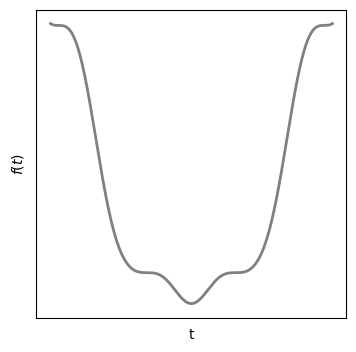

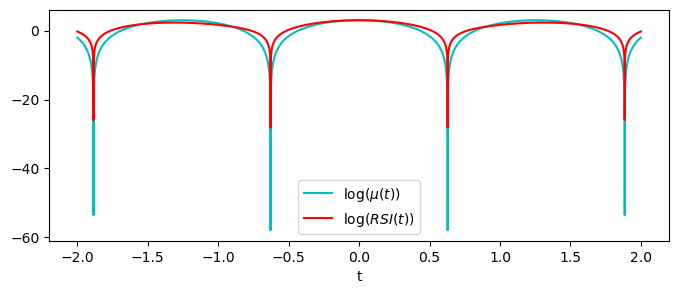

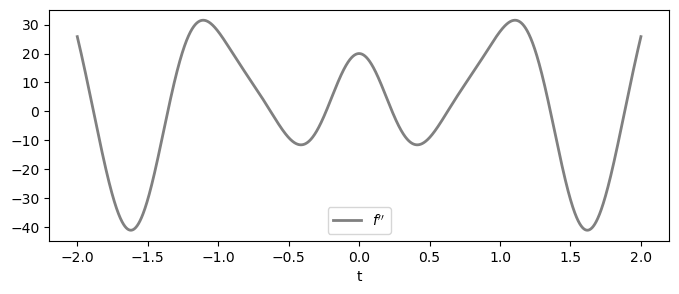

In [11]:
### -- PLOT -- ###

plt.figure(figsize=(4, 4))
plt.plot(tt, functions_values, lw=2, color="grey")

# plt.plot(tt,0.5*qg_upp*tt**2, label = "quadratic UB")
# plt.plot(tt,0.5*qg_inf*tt**2, label = "quadratic LB")
# plt.xticks([])
plt.xticks([])
plt.yticks([])
plt.ylabel(r"$f(t)$")
plt.xlabel("t")
#plt.legend(loc=4,edgecolor=(1,1,1),fontsize=fontsize)
#plt.legend()
plt.savefig("figures/f_1d_graph.pdf", dpi=300, bbox_inches="tight")
plt.figure(figsize=(8,3))
plt.plot(tt,np.log(pl),color="c",label=r'$\log(\mu(t))$')
plt.plot(tt,np.log(rsi),color = "r",label=r"$\log(RSI(t))$")
plt.yticks([0,-20,-40,-60])
plt.xlabel("t")
plt.legend()
plt.savefig("figures/f_1d_rsi_vs_pl.pdf", dpi=300, bbox_inches="tight")
plt.figure(figsize=(8,3))
plt.plot(tt, f_1d_hess(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f''$")
plt.xlabel("t")
plt.legend()
plt.savefig("figures/f_1d_rsi_vs_pl.pdf", dpi=300, bbox_inches="tight")

/tmp/ipykernel_14476/2266860868.py:7: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="r", label ="NM")
/tmp/ipykernel_14476/2266860868.py:21: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="r", label ="NMO")


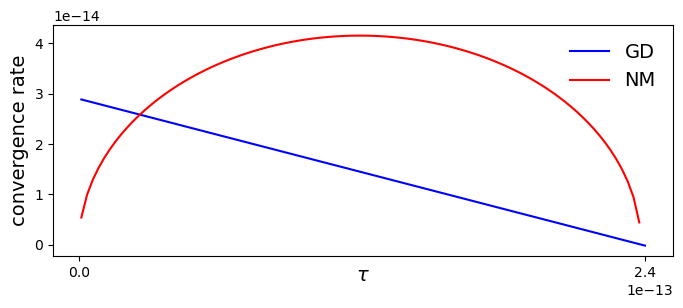

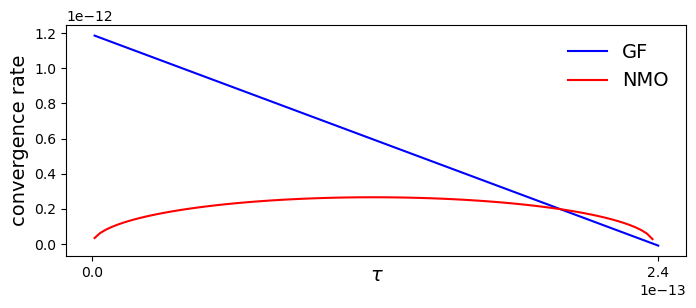

In [5]:
### -- Figure quasar convex -- ###
fontsize = 14
plt.figure(figsize=(8,3))
# plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="b", label =r'$\gamma \sqrt{\mu/L}$')
# plt.plot(gamma[0:],(vec_mu*gamma/L)[0:],color ="r",label=r'$\gamma\mu/L$')
plt.plot(gamma[0:],(vec_mu*gamma/L)[0:],color ="b",label="GD")
plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma/np.sqrt(L))[0:],color="r", label ="NM")

plt.xlabel(r'$\tau$',labelpad=-10,fontsize=fontsize)
plt.ylabel("convergence rate",fontsize=fontsize)
plt.xticks([0,2.4*10**(-13)])
# plt.yticks([0,1.5*10**(-14),3*10**(-14)])
# plt.yticks([0,2*10**(-14),3*10**(-14),4*10**(-14)])
plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/sqc_bound.pdf", dpi=300, bbox_inches="tight")

plt.figure(figsize=(8,3))
# plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="b", label =r'$\gamma \sqrt{\mu}$')
# plt.plot(gamma[0:],(vec_mu*gamma)[0:],color ="r",label=r'$\gamma\mu$')
plt.plot(gamma[0:],(vec_mu*gamma)[0:],color ="b",label="GF")
plt.plot(gamma[0:],(np.sqrt(vec_mu)*gamma)[0:],color="r", label ="NMO")

plt.xlabel(r'$\tau$',labelpad=-10,fontsize=fontsize)
plt.ylabel("convergence rate",fontsize=fontsize)
plt.xticks([0,2.4*10**(-13)])
# plt.yticks([0,6*10**(-13)])
plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/sqc_bound_cont.pdf", dpi=300, bbox_inches="tight")

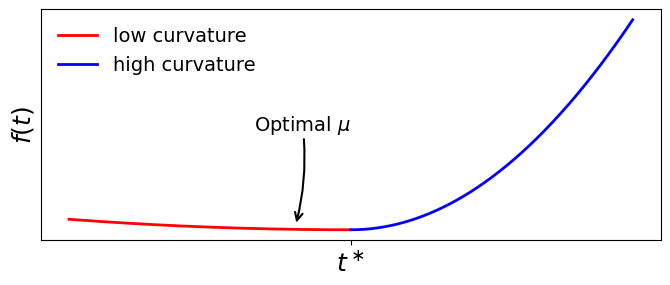

In [53]:




plt.figure(figsize=(8,3))
fontsize = 14
fontsize_ticks = 18
plt.plot(tt_minus,f_quadratic_worst_case(tt_minus,0.1,2),lw=2,color="r",label="low curvature")
plt.plot(tt_plus,f_quadratic_worst_case(tt_plus,0.1,2),lw=2,color="b",label ="high curvature")
# plt.xticks((-1,0,1))
# plt.yticks((0,1))
plt.xticks([0],[r"$t^\ast$"],fontsize=fontsize_ticks)
plt.yticks([])
# plt.xlabel(r'$t$',labelpad=0,fontsize=fontsize)
plt.ylabel(r"$f(t)$",labelpad=0,fontsize=fontsize_ticks)

# plt.xlabel(r'$t$',labelpad=0,fontsize=fontsize)
# plt.ylabel(r"$f(t)$",labelpad=-10,fontsize=fontsize)
x_low = -0.2
y_low = f_quadratic_worst_case(np.array([x_low]), 0.1, 2)[0]
plt.annotate(
    r'Optimal $\mu$',
    xy=(x_low, y_low),
    xytext=(0, 0.5),
    textcoords='data',
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        shrinkA=0, shrinkB=5,
        connectionstyle="arc3,rad=-0.1"
    ),
    fontsize=fontsize,
    ha='right', va='center'
)

plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/worst_case_quad.pdf", dpi=300, bbox_inches="tight")

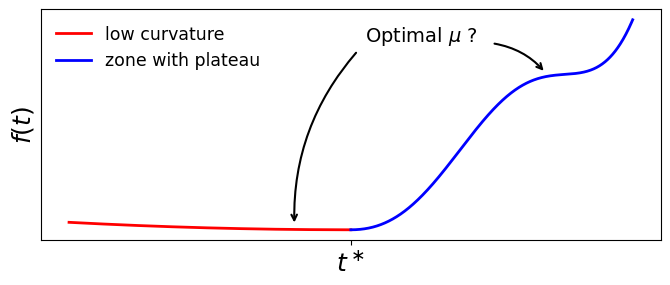

In [54]:

tt_minus = np.linspace(-1,0,1000)
tt_plus = np.linspace(0,1,1000)
plt.figure(figsize=(8,3))
fontsize = 14
fontsize_ticks = 18
plt.plot(tt_minus,f_pl_worst_case(tt_minus,0.1,1,2),lw=2,color="r",label="low curvature")
plt.plot(tt_plus,f_pl_worst_case(tt_plus,0.1,0.38,5),lw=2,color="b",label ="zone with plateau")
# plt.xticks((-1,0,1))
# plt.yticks((0,1))
plt.xticks([0],[r"$t^\ast$"],fontsize=fontsize_ticks)
plt.yticks([])
# plt.xlabel(r'$t$',labelpad=0,fontsize=fontsize)
plt.ylabel(r"$f(t)$",labelpad=0,fontsize=fontsize_ticks)

x_low = -0.2
y_low = f_quadratic_worst_case(np.array([x_low]), 0.1, 2)[0]

# Point sur la forte courbure (bleu)
x_high = 0.7
y_high = f_pl_worst_case(np.array([x_high]), 0.1,0.38, 5)[0]
# Position du texte (au milieu, un peu au-dessus)
text_x = 0.25
text_y = 1.3

plt.text(text_x, text_y, r"Optimal $\mu$ ?",
         fontsize=fontsize, ha='center', va='center')

# -------------------------------------------------------
# Deux flèches partant du texte vers les deux courbes
# -------------------------------------------------------

# Flèche vers faible courbure
plt.annotate(
    "",  # pas de texte, juste une flèche
    xy=(x_low, y_low),
    xytext=(text_x-0.225, text_y-0.1),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        shrinkA=2, shrinkB=5,
        connectionstyle="arc3,rad=0.2"
    )
)

# Flèche vers forte courbure
plt.annotate(
    "",
    xy=(x_high, y_high),
    xytext=(text_x+0.25, text_y-0.05),
    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        shrinkA=2, shrinkB=5,
        connectionstyle="arc3,rad=-0.2"
    )
)
plt.legend(edgecolor=(1,1,1),fontsize=fontsize-1.5,loc = "upper left")
plt.savefig("figures/worst_case_pl.pdf", dpi=300, bbox_inches="tight")

3.2185660399057494 18.240499951043418 0.040499999999999876 578.2138926241499


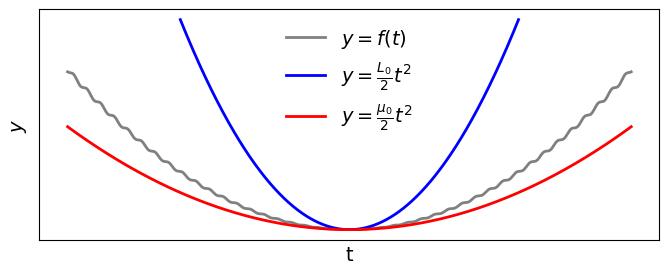

In [74]:

### Uncomment if not runed yet ###

# x_min = -10
# x_max = 10
# nb_step = 1000000
# tt = np.linspace(x_min, x_max, nb_step)
# a_1d = 0.07
# b_1d = 13
# L = np.max(np.abs(f_1d_hess(tt, a_1d, b_1d)))
# pl = 0.5*f_1d_deriv(tt,a_1d,b_1d)**2/f_1d(tt,a_1d,b_1d)
# rsi = np.abs(f_1d_deriv(tt,a_1d,b_1d)/(tt))
# qg =  2*f_1d(tt,a_1d,b_1d)/tt**2
# pl_const = np.min(pl)
# rsi_const  = np.min(rsi)
# qg_upp = np.max(qg)
# qg_inf = np.min(qg)
# arg_inf = np.argmin(rsi_const)
# print("Nest : ", (qg_inf/qg_upp)**(0.25) * np.sqrt(np.min(pl_const)/L), "GD : ", np.sqrt(np.min(pl_const)*qg_inf)/L)
# print(((qg_inf/qg_upp)**(0.25) * np.sqrt(np.min(pl_const)/L))/(np.sqrt(np.min(pl_const)*qg_inf)/L))

fontsize = 14
plt.figure(figsize=(8,3))
plt.plot(tt, f_1d(tt, a_1d, b_1d), lw=2, color="grey",label=r"$y = f(t)$")
# plt.plot(tt, f_1d_hess(tt, a_1d, b_1d), lw=2, color="grey",label=r"$f$")
plt.plot(tt[200000:800000],0.5*qg_upp*tt[200000:800000]**2, color="blue",label = r'$y= \frac{L_0}{2} t^2$',lw=2)
plt.plot(tt,0.5*qg_inf*tt**2,label = r'$y = \frac{\mu_0}{2} t^2$', color="red",lw=2)
np.max(np.abs( f_1d_hess(tt, a_1d, b_1d)))
print(qg_inf,qg_upp,pl_const,L)

plt.xlabel('t',labelpad=0,fontsize=fontsize)
plt.ylabel(r"$y$",fontsize=fontsize)
plt.xticks([])
plt.yticks([])
# plt.yticks([0,2*10**(-14),3*10**(-14),4*10**(-14)])
plt.legend(edgecolor=(1,1,1),fontsize=fontsize)
plt.savefig("figures/quad_bound_diff.pdf", dpi=300, bbox_inches="tight")

In [73]:
0.04/578

6.920415224913495e-05

In [58]:
f_1d_deriv(tt,a_1d,b_1d)[500000:].min()

0.0001824051814351779